Section 1: Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12,6)

Section 2: Load Dataset

In [5]:
nifty = pd.read_csv("../data/raw/NIFTY 50_Historical_PR_01011990to11102024.csv")
stocks = pd.read_csv("../data/raw/NIFTY50_all.csv")

nifty.head()

,Index Name,Date,Open,High,Low,Close
0,NIFTY 50,11 Oct 2024,24985.3,25028.65,24920.05,24964.25
1,NIFTY 50,10 Oct 2024,25067.05,25134.05,24979.4,24998.45
2,NIFTY 50,09 Oct 2024,25065.8,25234.05,24947.7,24981.95
3,NIFTY 50,08 Oct 2024,24832.2,25044,24756.8,25013.15
4,NIFTY 50,07 Oct 2024,25084.1,25143,24694.35,24795.75


Section 3: Data Overview

In [6]:
nifty.info()
nifty.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8325 entries, 0 to 8324
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Index Name  8325 non-null   object 
 1   Date        8325 non-null   object 
 2   Open        8325 non-null   object 
 3   High        8325 non-null   object 
 4   Low         8325 non-null   object 
 5   Close       8325 non-null   float64
dtypes: float64(1), object(5)
memory usage: 390.4+ KB


,Close
count,8325.000000
mean,5734.250411
std,5737.177418
min,279.020000
25%,1119.480000
50%,4111.150000
75%,8459.650000
max,26216.050000


Section 4: Data Cleaning

In [7]:
nifty['Date'] = pd.to_datetime(nifty['Date'])
nifty.set_index('Date', inplace=True)
nifty.sort_index(inplace=True)

nifty = nifty.dropna()

Section 5: Price Visualization

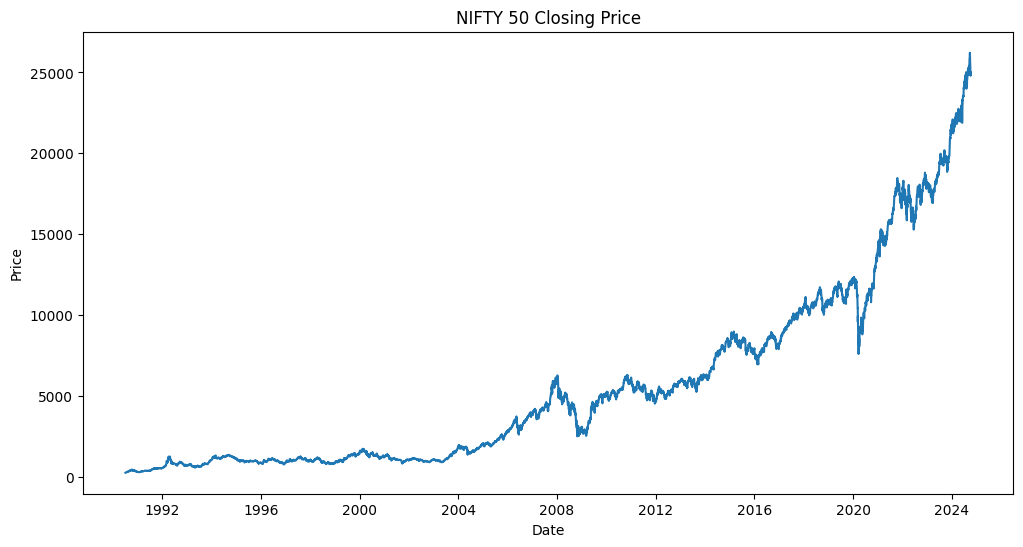

In [8]:
plt.plot(nifty['Close'])
plt.title("NIFTY 50 Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

Section 6: Returns

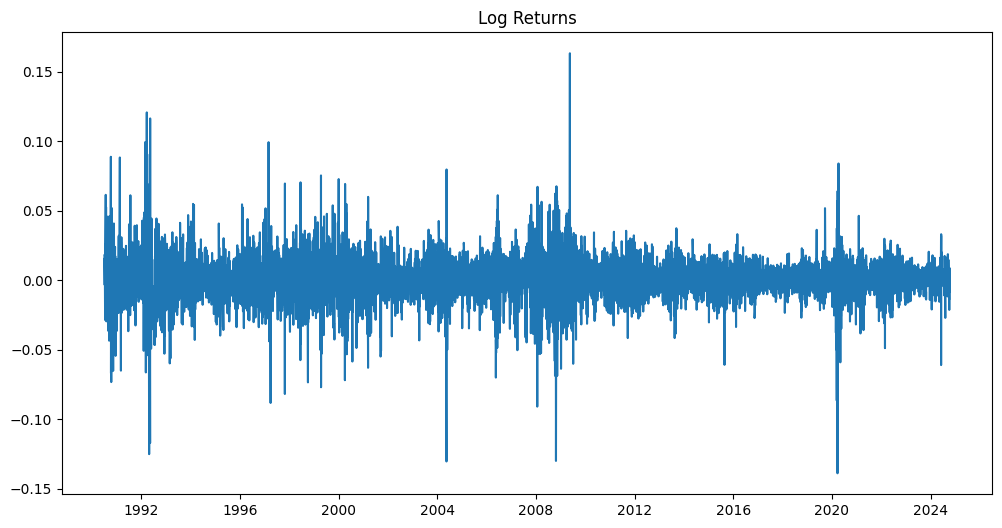

In [9]:
nifty['Returns'] = np.log(nifty['Close'] / nifty['Close'].shift(1))

plt.plot(nifty['Returns'])
plt.title("Log Returns")
plt.show()

Section 7: Volatility

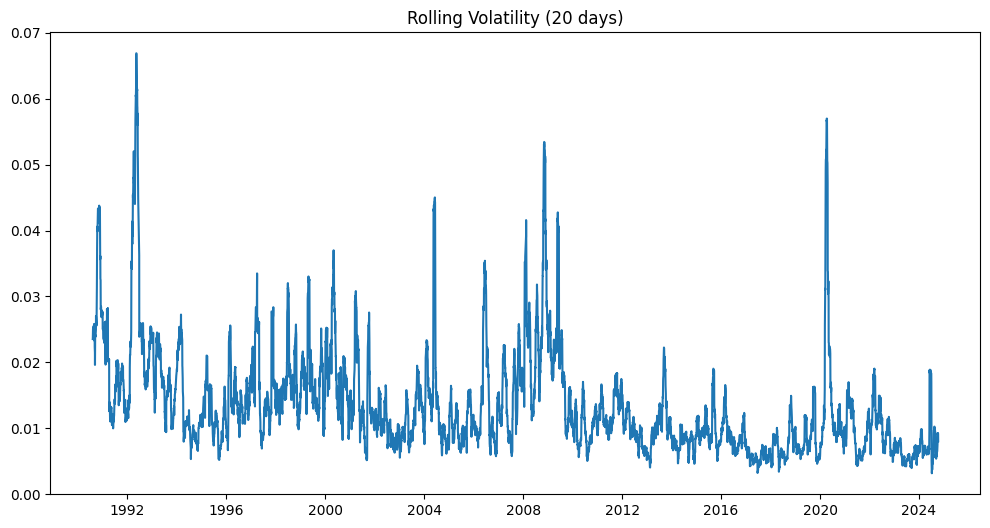

In [10]:
nifty['Volatility'] = nifty['Returns'].rolling(window=20).std()

plt.plot(nifty['Volatility'])
plt.title("Rolling Volatility (20 days)")
plt.show()

Section 8: Stocks Dataset (Advanced)

In [11]:
stocks['Date'] = pd.to_datetime(stocks['Date'])
stocks.set_index('Date', inplace=True)
stocks.sort_index(inplace=True)

Section 9: Select Few Stocks

In [12]:
selected = stocks[stocks['Symbol'].isin(['RELIANCE','TCS','INFY'])]

pivot = selected.pivot(columns='Symbol', values='Close')

returns = np.log(pivot / pivot.shift(1))

Section 10: Compare Returns

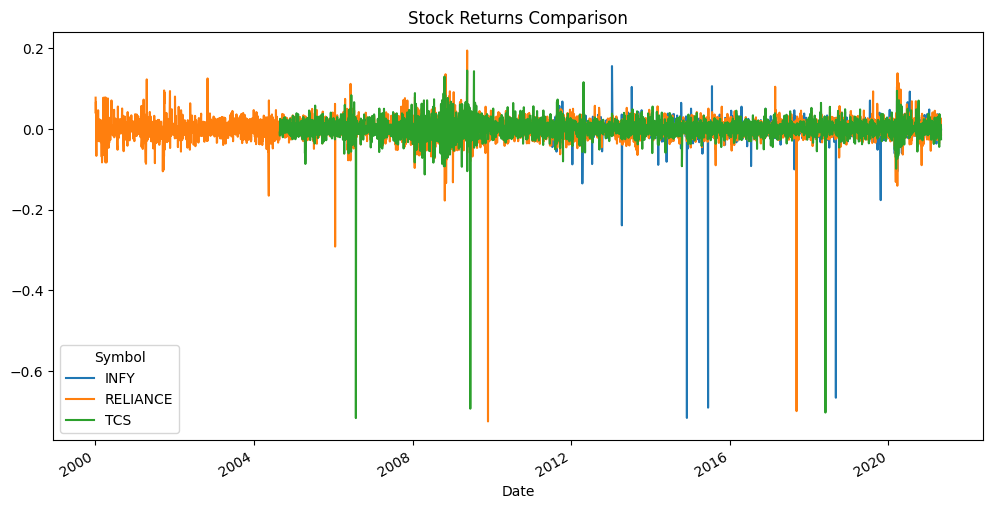

In [13]:
returns.plot()
plt.title("Stock Returns Comparison")
plt.show()

Section 11: Correlation Heatmap

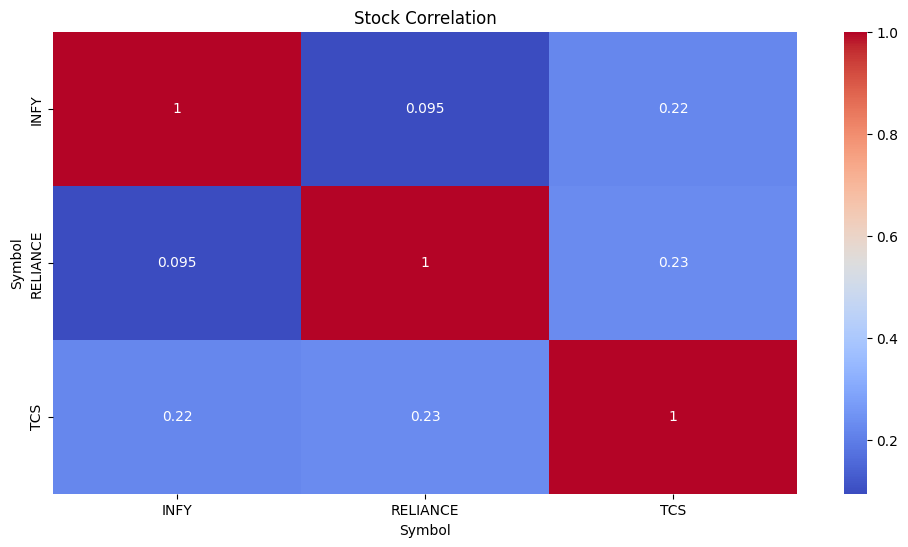

In [14]:
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Stock Correlation")
plt.show()

In [15]:
nifty.to_csv("../data/processed/nifty_clean.csv")
returns.to_csv("../data/processed/stocks_returns.csv")